In [1]:
!pip install -q torch torchvision pillow kagglehub boto3 tqdm

In [2]:
import os
import copy
import shutil
import random
from pathlib import Path
from PIL import Image
import boto3
from botocore import UNSIGNED
from botocore.config import Config
from tqdm import tqdm
import kagglehub

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

device = torch.device("mps:0" if torch.backends.mps.is_available() else
                       "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps:0


## 1. Download datasets

**Fake plants** → Kaggle `ayasaadamin/fake-plants` (folder: `Fake Plants`)  
**Real plants** → Kaggle `emmarex/plantdisease` (PlantVillage) + optional PlantDoc from S3

In [3]:
# ── Download fake-plant images from Kaggle ──────────────────────────────────
print("Downloading fake plants dataset...")
fake_kaggle_path = kagglehub.dataset_download("ayasaadamin/fake-plants")
print(f"Fake plants cached at: {fake_kaggle_path}")

# Show what's inside so we can pick the right sub-folder
for root, dirs, files in os.walk(fake_kaggle_path):
    level = root.replace(fake_kaggle_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")
    if level >= 2:
        break

Fake plants cached at: /Users/avnay/.cache/kagglehub/datasets/ayasaadamin/fake-plants/versions/1
1/  (0 files)
  Fake Plants/  (0 files)
    test_fake/  (120 files)


In [4]:
# ── Download PlantVillage (real plants) from Kaggle ──────────────────────────
print("Downloading PlantVillage dataset...")
pv_kaggle_path = kagglehub.dataset_download("emmarex/plantdisease")
print(f"PlantVillage cached at: {pv_kaggle_path}")

PlantVillage cached at: /Users/avnay/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1


In [5]:
# ── (Optional) Download PlantDoc images from S3 ───────────────────────────────
# Set USE_PLANTDOC_S3 = True and fill in your bucket/prefix if you have
# the PlantDoc training images stored there.

USE_PLANTDOC_S3 = False          # ← flip to True to enable
S3_BUCKET       = "plant-ai-weights-avnay"
S3_PREFIX       = "plantdoc/train/"   # prefix under which real-plant images live
LOCAL_PLANTDOC  = "./plantdoc_real"   # where to save them locally

if USE_PLANTDOC_S3:
    os.makedirs(LOCAL_PLANTDOC, exist_ok=True)
    s3 = boto3.client("s3", region_name="ap-southeast-1")
    paginator = s3.get_paginator("list_objects_v2")
    pages = paginator.paginate(Bucket=S3_BUCKET, Prefix=S3_PREFIX)
    keys = [obj["Key"] for page in pages for obj in page.get("Contents", [])]
    print(f"Found {len(keys)} objects under s3://{S3_BUCKET}/{S3_PREFIX}")
    for key in tqdm(keys, desc="Downloading PlantDoc from S3"):
        dest = os.path.join(LOCAL_PLANTDOC, os.path.basename(key))
        if not os.path.exists(dest):
            s3.download_file(S3_BUCKET, key, dest)
    print("Done.")
else:
    print("Skipping PlantDoc S3 download (USE_PLANTDOC_S3 = False)")

Skipping PlantDoc S3 download (USE_PLANTDOC_S3 = False)


## 2. Organise into ImageFolder structure

```
plant_dataset/
  train/
    fake/   ← artificial plant images
    real/   ← real plant images (PlantVillage + optional PlantDoc)
  val/
    fake/
    real/
```

80 % train / 20 % val split, shuffled.

In [6]:
VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
VAL_RATIO  = 0.20
SEED       = 42
DATA_DIR   = Path("./plant_dataset")

def collect_images(root: Path) -> list[Path]:
    """Recursively collect all image paths under `root`."""
    return [p for p in root.rglob("*") if p.suffix.lower() in VALID_EXT]

def copy_split(images: list[Path], dst_train: Path, dst_val: Path,
               val_ratio: float = VAL_RATIO, seed: int = SEED):
    """Shuffle images, split, and hard-link (copy) into dst folders."""
    random.seed(seed)
    shuffled = images.copy()
    random.shuffle(shuffled)
    n_val = int(len(shuffled) * val_ratio)
    val_imgs   = shuffled[:n_val]
    train_imgs = shuffled[n_val:]

    for imgs, dst in [(train_imgs, dst_train), (val_imgs, dst_val)]:
        dst.mkdir(parents=True, exist_ok=True)
        for src in imgs:
            dest_file = dst / src.name
            # avoid name collisions by appending a counter suffix
            if dest_file.exists():
                stem, suffix = src.stem, src.suffix
                counter = 1
                while dest_file.exists():
                    dest_file = dst / f"{stem}_{counter}{suffix}"
                    counter += 1
            shutil.copy2(src, dest_file)

    return len(train_imgs), len(val_imgs)

# ── Fake images ──────────────────────────────────────────────────────────────
fake_root = Path(fake_kaggle_path)
# The Kaggle dataset has a "Fake Plants" sub-folder; handle both cases
fake_subdir = fake_root / "Fake Plants"
if not fake_subdir.exists():
    fake_subdir = fake_root   # images directly under root

fake_images = collect_images(fake_subdir)
print(f"Found {len(fake_images)} fake-plant images")

n_fake_train, n_fake_val = copy_split(
    fake_images,
    DATA_DIR / "train" / "fake",
    DATA_DIR / "val"   / "fake",
)
print(f"  → {n_fake_train} train  |  {n_fake_val} val")

# ── Real images (PlantVillage) ───────────────────────────────────────────────
pv_root = Path(pv_kaggle_path)
pv_subdir = pv_root / "PlantVillage"
if not pv_subdir.exists():
    pv_subdir = pv_root

real_images = collect_images(pv_subdir)
print(f"Found {len(real_images)} PlantVillage (real) images")

# ── Real images (PlantDoc from S3, if enabled) ───────────────────────────────
if USE_PLANTDOC_S3:
    pd_images = collect_images(Path(LOCAL_PLANTDOC))
    print(f"Found {len(pd_images)} PlantDoc (real) images from S3")
    real_images.extend(pd_images)

print(f"Total real-plant images: {len(real_images)}")

# Cap real images to 5× the fake count to avoid severe class imbalance
max_real = len(fake_images) * 5
if len(real_images) > max_real:
    random.seed(SEED)
    real_images = random.sample(real_images, max_real)
    print(f"  → Sampled down to {len(real_images)} real images (5× fake count)")

n_real_train, n_real_val = copy_split(
    real_images,
    DATA_DIR / "train" / "real",
    DATA_DIR / "val"   / "real",
)
print(f"  → {n_real_train} train  |  {n_real_val} val")

print("\nDataset ready at:", DATA_DIR.resolve())

Found 509 fake-plant images
  → 408 train  |  101 val
Found 41276 PlantVillage (real) images
Total real-plant images: 41276
  → Sampled down to 2545 real images (5× fake count)
  → 2036 train  |  509 val

Dataset ready at: /Users/avnay/Desktop/AIML/Plant_project/Notebook/plant_dataset


## 3. Data loaders

In [14]:
from pathlib import Path

# Update this path to where your dataset lives
data_dir = "/Users/avnay/Desktop/AIML/Plant_project/fake_plant_dataset"

data_transforms = {
    "train": transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
    "val": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
}

image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ["train", "val"]
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x == "train"),
                  num_workers=0, pin_memory=False)
    for x in ["train", "val"]
}

dataset_sizes = {x: len(image_datasets[x]) for x in ["train", "val"]}
class_names   = image_datasets["train"].classes   # ['fake', 'real']

print(f"Classes: {class_names}")
print(f"Train size: {dataset_sizes['train']}  |  Val size: {dataset_sizes['val']}")

Classes: ['fake', 'real']
Train size: 2852  |  Val size: 711


## 4. Model — ResNet-50 binary classifier (fake vs real)

In [18]:
weights = models.ResNet50_Weights.DEFAULT
model   = models.resnet50(weights=weights)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4 for domain-specific fine-tuning
for param in model.layer4.parameters():
    param.requires_grad = True

# Use differential learning rates
optimizer = optim.AdamW([
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3}
], weight_decay=1e-2)

# Replace head — deeper dropout stack to fight overfitting on small dataset
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_ftrs, 2),
    nn.ReLU())

model = model.to(device)

# AdamW + weight decay regularises the head weights
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-2)

# ReduceLROnPlateau halves LR only when val loss stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

print("Model ready. Head parameters to train:",
      sum(p.numel() for p in model.fc.parameters() if p.requires_grad))

Model ready. Head parameters to train: 4098


## 5. Training

In [10]:
def train_test_step(
    model: nn.Module,
    train_dataloader,
    test_dataloader,
    loss_fn,
    optimizer,
    scheduler,  
    device,
):
    # Training phase
    model.train()
    train_loss, train_acc = 0, 0

    # Removed tqdm here so it doesn't spam batches
    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = y_pred.argmax(dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    if device.type == "mps":
        torch.mps.empty_cache()

    # Evaluation phase
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for batch, (X, y) in enumerate(test_dataloader):
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    if device.type == "mps":
        torch.mps.empty_cache()

    return train_loss, train_acc, test_loss, test_acc

In [11]:
def EvalModel(
    EPOCHS,
    train_dataloader,
    valid_dataloader,
    model,
    loss_fn,
    optimizer,
    scheduler,
    device,
    save_path=None,
):
    best_val_acc = 0.0
    best_wts = copy.deepcopy(model.state_dict())

    for epoch in tqdm(range(EPOCHS), desc="Training Progress"):

        train_loss, train_acc, val_loss, val_acc = train_test_step(
            model=model,
            train_dataloader=train_dataloader,
            test_dataloader=valid_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            scheduler=scheduler,
            device=device,
        )

        # Step the scheduler, passing val_loss for ReduceLROnPlateau
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        print(
            f"Epoch:{epoch} | Train Loss: {train_loss:.4f} | Train Acc:"
            f" {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc:"
            f" {val_acc*100:.2f}%"
        )

        # Track and save the best weights
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_wts = copy.deepcopy(model.state_dict())
            if save_path:
                torch.save(best_wts, save_path)
                print(f"  ✓ Best model saved (val acc: {best_val_acc*100:.2f}%) → {save_path}")

    print(f"\nBest Val Acc: {best_val_acc*100:.2f}%")
    model.load_state_dict(best_wts)
    return model

In [23]:
print("Train class counts:", image_datasets["train"].targets.count(0), "class 0,", image_datasets["train"].targets.count(1), "class 1")

Train class counts: 816 class 0, 2036 class 1


In [24]:
model.eval()
with torch.no_grad():
    for inputs, labels in dataloaders["val"]:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        if 1 in labels:  # Find a batch with at least one 'real' plant
            print("Batch Predictions:", preds.cpu().numpy())
            print("Batch Actuals:    ", labels.cpu().numpy())
            break

Batch Predictions: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Batch Actuals:     [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [21]:
if torch.backends.mps.is_available():
    # Clear unused cached memory from the M2 unified memory
    torch.mps.empty_cache()
    print("MPS cache cleared.")

MPS cache cleared.


In [26]:
train_test_step(
    model=model,
    train_dataloader=dataloaders["train"],
    test_dataloader=dataloaders["val"],
    loss_fn=criterion,
    optimizer=optimizer,
    scheduler=None,
    device=device,
)

# Full training run — best weights auto-saved to disk
LOCAL_MODEL_PATH = "fake_vs_real_resnet50.pth"

model = EvalModel(
    EPOCHS=2,
    train_dataloader=dataloaders["train"],
    valid_dataloader=dataloaders["val"],
    model=model,
    loss_fn=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_path=LOCAL_MODEL_PATH,
)

Training Progress:   0%|                                  | 0/2 [00:00<?, ?it/s]

Epoch:0 | Train Loss: 0.2106 | Train Acc: 99.93% | Val Loss: 0.2046 | Val Acc: 100.00%


Training Progress:  50%|█████████████             | 1/2 [01:23<01:23, 83.89s/it]

  ✓ Best model saved (val acc: 100.00%) → fake_vs_real_resnet50.pth


Training Progress: 100%|██████████████████████████| 2/2 [03:07<00:00, 93.69s/it]

Epoch:1 | Train Loss: 0.2171 | Train Acc: 99.34% | Val Loss: 0.2046 | Val Acc: 100.00%

Best Val Acc: 100.00%


              precision    recall  f1-score   support

        fake       1.00      1.00      1.00       202
        real       1.00      1.00      1.00       509

    accuracy                           1.00       711
   macro avg       1.00      1.00      1.00       711
weighted avg       1.00      1.00      1.00       711



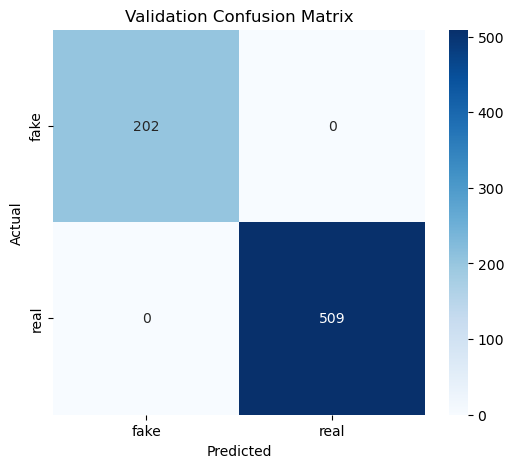

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import torch

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in dataloaders["val"]:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Print detailed classification metrics
print(classification_report(all_labels, all_preds, target_names=class_names))

# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")
plt.show()

## 6. Save model locally and upload to S3

In [ ]:
LOCAL_MODEL_PATH = "fake_vs_real_resnet50.pth"
torch.save(model.state_dict(), LOCAL_MODEL_PATH)
print(f"Model saved locally: {LOCAL_MODEL_PATH}")

# ── Upload to S3 ─────────────────────────────────────────────────────────────
UPLOAD_TO_S3 = False   # ← set True once you're happy with the model
S3_MODEL_KEY = "fake_vs_real_resnet50.pth"

if UPLOAD_TO_S3:
    s3_client = boto3.client("s3", region_name="ap-southeast-1")
    s3_client.upload_file(LOCAL_MODEL_PATH, S3_BUCKET, S3_MODEL_KEY)
    url = f"https://{S3_BUCKET}.s3.ap-southeast-1.amazonaws.com/{S3_MODEL_KEY}"
    print(f"Uploaded to S3: {url}")
else:
    print("Skipping S3 upload (UPLOAD_TO_S3 = False)")

## 7. Quick inference test

In [28]:
def predict_fake_or_real(image_path: str) -> dict:
    """Return {'label': 'fake'|'real', 'confidence': float} for a single image."""
    infer_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    img = Image.open(image_path).convert("RGB")
    tensor = infer_transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1)[0]
        pred   = torch.argmax(probs).item()

    return {
        "label":      class_names[pred],
        "confidence": round(probs[pred].item(), 4),
        "fake_prob":  round(probs[0].item(), 4),
        "real_prob":  round(probs[1].item(), 4),
    }

# Example — swap in any image path:
image_path = os.path.expanduser("~/Desktop/AIML/Plant_project/fake_plant_dataset/val/real/0a7f1993-85ae-4ba4-865b-df96bb0b52b4___YLCV_NREC 2416.JPG")

result = predict_fake_or_real(image_path)
print(result)


{'label': 'real', 'confidence': 0.9296, 'fake_prob': 0.0704, 'real_prob': 0.9296}
